In [1]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [2]:
df_train = pd.read_excel("Asssignment4_Data.xlsx", sheet_name="Train")
df_test = pd.read_excel("Asssignment4_Data.xlsx", sheet_name="Test")

TARGET_COL = "Construction type"
FEATURE_COLS = list(set(df_train.columns) - set([TARGET_COL]))
CLASSES = set(x for x in df_train[TARGET_COL] if type(x) is str)
CLASS_PROBS = {
    cls: count / len(df_train[TARGET_COL])
    for cls, count in Counter(df_train[TARGET_COL]).items()
}

# Part 1

## Conditional Probabilities

| Feature | Class | Values | Conditional Probability |
|-|-|-|-|
| Living area | Condo | $1.175$, $0.988$, $1.24$, $3.42$, $1.121$, $1.376$ | $\mu=\frac{1.175+0.988+1.24+3.42+1.121+1.376}{6}=1.553$; $\sigma=\frac{(1.175-1.553)^2+(0.988-1.553)^2+(1.24-1.553)^2+(3.42-1.553)^2+(1.121-1.553)^2+(1.376-1.553)^2}{6-1}=0.843$; $P=\frac{1}{\sqrt{2\pi\cdot0.843^2}}\exp\left(-\frac{(x-1.553)^2}{2(0.843)^2}\right)$ |
| Land Area | Condo | $2.275$, $4.455$, $5.85$, $9.8$, $6.666$, $7.102$ | $\mu=\frac{2.275+4.455+5.85+9.8+6.666+7.102}{6}=6.025$; $\sigma=\frac{(2.275-6.025)^2+(4.455-6.025)^2+(5.85-6.025)^2+(9.8-6.025)^2+(6.666-6.025)^2+(7.102-6.025)^2}{6-1}=2.323$; $P=\frac{1}{\sqrt{2\pi\cdot2.323^2}}\exp\left(-\frac{(x-6.025)^2}{2(2.323)^2}\right)$ |
| Age of home | Condo | $40$, $56$, $51$, $42$, $32$, $17$ | $\mu=\frac{40+56+51+42+32+17}{6}=39.667$; $\sigma=\frac{(40-39.667)^2+(56-39.667)^2+(51-39.667)^2+(42-39.667)^2+(32-39.667)^2+(17-39.667)^2}{6-1}=12.737$; $P=\frac{1}{\sqrt{2\pi\cdot12.737^2}}\exp\left(-\frac{(x-39.667)^2}{2(12.737)^2}\right)$ |
| # Bedrooms | Condo | $3$, $3$, $3$, $5$, $3$, $3$ | $\mu=\frac{3+3+3+5+3+3}{6}=3.333$; $\sigma=\frac{(3-3.333)^2+(3-3.333)^2+(3-3.333)^2+(5-3.333)^2+(3-3.333)^2+(3-3.333)^2}{6-1}=0.745$; $P=\frac{1}{\sqrt{2\pi\cdot0.745^2}}\exp\left(-\frac{(x-3.333)^2}{2(0.745)^2}\right)$ |
| Bathrooms | Condo | $1.0$, $1.0$, $1.0$, $2.5$, $1.0$, $1.5$ | $\mu=\frac{1.0+1.0+1.0+2.5+1.0+1.5}{6}=1.333$; $\sigma=\frac{(1.0-1.333)^2+(1.0-1.333)^2+(1.0-1.333)^2+(2.5-1.333)^2+(1.0-1.333)^2+(1.5-1.333)^2}{6-1}=0.553$; $P=\frac{1}{\sqrt{2\pi\cdot0.553^2}}\exp\left(-\frac{(x-1.333)^2}{2(0.553)^2}\right)$ |
| # Rooms | Condo | $6$, $6$, $7$, $10$, $6$, $6$ | $\mu=\frac{6+6+7+10+6+6}{6}=6.833$; $\sigma=\frac{(6-6.833)^2+(6-6.833)^2+(7-6.833)^2+(10-6.833)^2+(6-6.833)^2+(6-6.833)^2}{6-1}=1.462$; $P=\frac{1}{\sqrt{2\pi\cdot1.462^2}}\exp\left(-\frac{(x-6.833)^2}{2(1.462)^2}\right)$ |
| House ID | Condo | $3$, $6$, $7$, $9$, $14$, $19$ | $\mu=\frac{3+6+7+9+14+19}{6}=9.667$; $\sigma=\frac{(3-9.667)^2+(6-9.667)^2+(7-9.667)^2+(9-9.667)^2+(14-9.667)^2+(19-9.667)^2}{6-1}=5.344$; $P=\frac{1}{\sqrt{2\pi\cdot5.344^2}}\exp\left(-\frac{(x-9.667)^2}{2(5.344)^2}\right)$ |
| # Garages | Condo | $1.0$, $1.0$, $1.0$, $2.0$, $2.0$, $1.0$ | $\mu=\frac{1.0+1.0+1.0+2.0+2.0+1.0}{6}=1.333$; $\sigma=\frac{(1.0-1.333)^2+(1.0-1.333)^2+(1.0-1.333)^2+(2.0-1.333)^2+(2.0-1.333)^2+(1.0-1.333)^2}{6-1}=0.471$; $P=\frac{1}{\sqrt{2\pi\cdot0.471^2}}\exp\left(-\frac{(x-1.333)^2}{2(0.471)^2}\right)$ |
| Local Price | Condo | $4.5429$, $3.891$, $5.898$, $16.4202$, $5.9592$, $7.7841$ | $\mu=\frac{4.5429+3.891+5.898+16.4202+5.9592+7.7841}{6}=7.416$; $\sigma=\frac{(4.5429-7.416)^2+(3.891-7.416)^2+(5.898-7.416)^2+(16.4202-7.416)^2+(5.9592-7.416)^2+(7.7841-7.416)^2}{6-1}=4.209$; $P=\frac{1}{\sqrt{2\pi\cdot4.209^2}}\exp\left(-\frac{(x-7.416)^2}{2(4.209)^2}\right)$ |
| Living area | House | $1.5$, $1.501$, $1.225$, $1.552$, $0.975$, $1.501$, $1.488$ | $\mu=\frac{1.5+1.501+1.225+1.552+0.975+1.501+1.488}{7}=1.392$; $\sigma=\frac{(1.5-1.392)^2+(1.501-1.392)^2+(1.225-1.392)^2+(1.552-1.392)^2+(0.975-1.392)^2+(1.501-1.392)^2+(1.488-1.392)^2}{7-1}=0.197$; $P=\frac{1}{\sqrt{2\pi\cdot0.197^2}}\exp\left(-\frac{(x-1.392)^2}{2(0.197)^2}\right)$ |
| Land Area | House | $3.531$, $9.52$, $6.435$, $4.9883$, $5.52$, $9.52$, $6.902$ | $\mu=\frac{3.531+9.52+6.435+4.9883+5.52+9.52+6.902}{7}=6.631$; $\sigma=\frac{(3.531-6.631)^2+(9.52-6.631)^2+(6.435-6.631)^2+(4.9883-6.631)^2+(5.52-6.631)^2+(9.52-6.631)^2+(6.902-6.631)^2}{7-1}=2.082$; $P=\frac{1}{\sqrt{2\pi\cdot2.082^2}}\exp\left(-\frac{(x-6.631)^2}{2(2.082)^2}\right)$ |
| Age of home | House | $62$, $32$, $32$, $30$, $30$, $32$, $22$ | $\mu=\frac{62+32+32+30+30+32+22}{7}=34.286$; $\sigma=\frac{(62-34.286)^2+(32-34.286)^2+(32-34.286)^2+(30-34.286)^2+(30-34.286)^2+(32-34.286)^2+(22-34.286)^2}{7-1}=11.780$; $P=\frac{1}{\sqrt{2\pi\cdot11.780^2}}\exp\left(-\frac{(x-34.286)^2}{2(11.780)^2}\right)$ |
| # Bedrooms | House | $4$, $3$, $3$, $3$, $2$, $3$, $3$ | $\mu=\frac{4+3+3+3+2+3+3}{7}=3.000$; $\sigma=\frac{(4-3.000)^2+(3-3.000)^2+(3-3.000)^2+(3-3.000)^2+(2-3.000)^2+(3-3.000)^2+(3-3.000)^2}{7-1}=0.535$; $P=\frac{1}{\sqrt{2\pi\cdot0.535^2}}\exp\left(-\frac{(x-3.000)^2}{2(0.535)^2}\right)$ |
| Bathrooms | House | $1.0$, $1.0$, $1.0$, $1.0$, $1.0$, $1.0$, $1.5$ | $\mu=\frac{1.0+1.0+1.0+1.0+1.0+1.0+1.5}{7}=1.071$; $\sigma=\frac{(1.0-1.071)^2+(1.0-1.071)^2+(1.0-1.071)^2+(1.0-1.071)^2+(1.0-1.071)^2+(1.0-1.071)^2+(1.5-1.071)^2}{7-1}=0.175$; $P=\frac{1}{\sqrt{2\pi\cdot0.175^2}}\exp\left(-\frac{(x-1.071)^2}{2(0.175)^2}\right)$ |
| # Rooms | House | $7$, $6$, $6$, $6$, $5$, $6$, $7$ | $\mu=\frac{7+6+6+6+5+6+7}{7}=6.143$; $\sigma=\frac{(7-6.143)^2+(6-6.143)^2+(6-6.143)^2+(6-6.143)^2+(5-6.143)^2+(6-6.143)^2+(7-6.143)^2}{7-1}=0.639$; $P=\frac{1}{\sqrt{2\pi\cdot0.639^2}}\exp\left(-\frac{(x-6.143)^2}{2(0.639)^2}\right)$ |
| House ID | House | $2$, $8$, $11$, $12$, $13$, $16$, $18$ | $\mu=\frac{2+8+11+12+13+16+18}{7}=11.429$; $\sigma=\frac{(2-11.429)^2+(8-11.429)^2+(11-11.429)^2+(12-11.429)^2+(13-11.429)^2+(16-11.429)^2+(18-11.429)^2}{7-1}=4.895$; $P=\frac{1}{\sqrt{2\pi\cdot4.895^2}}\exp\left(-\frac{(x-11.429)^2}{2(4.895)^2}\right)$ |
| # Garages | House | $2.0$, $0.0$, $2.0$, $1.0$, $1.0$, $0.0$, $1.5$ | $\mu=\frac{2.0+0.0+2.0+1.0+1.0+0.0+1.5}{7}=1.071$; $\sigma=\frac{(2.0-1.071)^2+(0.0-1.071)^2+(2.0-1.071)^2+(1.0-1.071)^2+(1.0-1.071)^2+(0.0-1.071)^2+(1.5-1.071)^2}{7-1}=0.776$; $P=\frac{1}{\sqrt{2\pi\cdot0.776^2}}\exp\left(-\frac{(x-1.071)^2}{2(0.776)^2}\right)$ |
| Local Price | House | $5.0208$, $5.6039$, $5.8282$, $5.3003$, $6.2712$, $5.6039$, $6.6969$ | $\mu=\frac{5.0208+5.6039+5.8282+5.3003+6.2712+5.6039+6.6969}{7}=5.761$; $\sigma=\frac{(5.0208-5.761)^2+(5.6039-5.761)^2+(5.8282-5.761)^2+(5.3003-5.761)^2+(6.2712-5.761)^2+(5.6039-5.761)^2+(6.6969-5.761)^2}{7-1}=0.528$; $P=\frac{1}{\sqrt{2\pi\cdot0.528^2}}\exp\left(-\frac{(x-5.761)^2}{2(0.528)^2}\right)$ |
| Living area | Apartment | $0.998$, $1.232$, $1.121$, $3.0$, $1.02$, $1.664$, $1.5$ | $\mu=\frac{0.998+1.232+1.121+3.0+1.02+1.664+1.5}{7}=1.505$; $\sigma=\frac{(0.998-1.505)^2+(1.232-1.505)^2+(1.121-1.505)^2+(3.0-1.505)^2+(1.02-1.505)^2+(1.664-1.505)^2+(1.5-1.505)^2}{7-1}=0.652$; $P=\frac{1}{\sqrt{2\pi\cdot0.652^2}}\exp\left(-\frac{(x-1.505)^2}{2(0.652)^2}\right)$ |
| Land Area | Apartment | $3.472$, $4.05$, $4.455$, $12.8$, $5.0$, $5.15$, $7.8$ | $\mu=\frac{3.472+4.05+4.455+12.8+5.0+5.15+7.8}{7}=6.104$; $\sigma=\frac{(3.472-6.104)^2+(4.05-6.104)^2+(4.455-6.104)^2+(12.8-6.104)^2+(5.0-6.104)^2+(5.15-6.104)^2+(7.8-6.104)^2}{7-1}=3.017$; $P=\frac{1}{\sqrt{2\pi\cdot3.017^2}}\exp\left(-\frac{(x-6.104)^2}{2(3.017)^2}\right)$ |
| Age of home | Apartment | $42$, $54$, $42$, $14$, $46$, $50$, $23$ | $\mu=\frac{42+54+42+14+46+50+23}{7}=38.714$; $\sigma=\frac{(42-38.714)^2+(54-38.714)^2+(42-38.714)^2+(14-38.714)^2+(46-38.714)^2+(50-38.714)^2+(23-38.714)^2}{7-1}=13.593$; $P=\frac{1}{\sqrt{2\pi\cdot13.593^2}}\exp\left(-\frac{(x-38.714)^2}{2(13.593)^2}\right)$ |
| # Bedrooms | Apartment | $4$, $3$, $3$, $5$, $2$, $4$, $3$ | $\mu=\frac{4+3+3+5+2+4+3}{7}=3.429$; $\sigma=\frac{(4-3.429)^2+(3-3.429)^2+(3-3.429)^2+(5-3.429)^2+(2-3.429)^2+(4-3.429)^2+(3-3.429)^2}{7-1}=0.904$; $P=\frac{1}{\sqrt{2\pi\cdot0.904^2}}\exp\left(-\frac{(x-3.429)^2}{2(0.904)^2}\right)$ |
| Bathrooms | Apartment | $1.0$, $1.0$, $1.0$, $2.5$, $1.0$, $1.5$, $1.0$ | $\mu=\frac{1.0+1.0+1.0+2.5+1.0+1.5+1.0}{7}=1.286$; $\sigma=\frac{(1.0-1.286)^2+(1.0-1.286)^2+(1.0-1.286)^2+(2.5-1.286)^2+(1.0-1.286)^2+(1.5-1.286)^2+(1.0-1.286)^2}{7-1}=0.525$; $P=\frac{1}{\sqrt{2\pi\cdot0.525^2}}\exp\left(-\frac{(x-1.286)^2}{2(0.525)^2}\right)$ |
| # Rooms | Apartment | $7$, $6$, $6$, $9$, $5$, $8$, $7$ | $\mu=\frac{7+6+6+9+5+8+7}{7}=6.857$; $\sigma=\frac{(7-6.857)^2+(6-6.857)^2+(6-6.857)^2+(9-6.857)^2+(5-6.857)^2+(8-6.857)^2+(7-6.857)^2}{7-1}=1.245$; $P=\frac{1}{\sqrt{2\pi\cdot1.245^2}}\exp\left(-\frac{(x-6.857)^2}{2(1.245)^2}\right)$ |
| House ID | Apartment | $1$, $4$, $5$, $10$, $15$, $17$, $20$ | $\mu=\frac{1+4+5+10+15+17+20}{7}=10.286$; $\sigma=\frac{(1-10.286)^2+(4-10.286)^2+(5-10.286)^2+(10-10.286)^2+(15-10.286)^2+(17-10.286)^2+(20-10.286)^2}{7-1}=6.713$; $P=\frac{1}{\sqrt{2\pi\cdot6.713^2}}\exp\left(-\frac{(x-10.286)^2}{2(6.713)^2}\right)$ |
| # Garages | Apartment | $1.0$, $1.0$, $1.0$, $2.0$, $0.0$, $2.0$, $1.5$ | $\mu=\frac{1.0+1.0+1.0+2.0+0.0+2.0+1.5}{7}=1.214$; $\sigma=\frac{(1.0-1.214)^2+(1.0-1.214)^2+(1.0-1.214)^2+(2.0-1.214)^2+(0.0-1.214)^2+(2.0-1.214)^2+(1.5-1.214)^2}{7-1}=0.647$; $P=\frac{1}{\sqrt{2\pi\cdot0.647^2}}\exp\left(-\frac{(x-1.214)^2}{2(0.647)^2}\right)$ |
| Local Price | Apartment | $4.9176$, $4.5573$, $5.0597$, $14.4598$, $5.05$, $8.2464$, $9.0384$ | $\mu=\frac{4.9176+4.5573+5.0597+14.4598+5.05+8.2464+9.0384}{7}=7.333$; $\sigma=\frac{(4.9176-7.333)^2+(4.5573-7.333)^2+(5.0597-7.333)^2+(14.4598-7.333)^2+(5.05-7.333)^2+(8.2464-7.333)^2+(9.0384-7.333)^2}{7-1}=3.348$; $P=\frac{1}{\sqrt{2\pi\cdot3.348^2}}\exp\left(-\frac{(x-7.333)^2}{2(3.348)^2}\right)$ |


In [3]:
CONDITIONAL_PROBS = {
    ('Condo', 'Living area'): (1.553, 0.843),
    ('Condo', 'Land Area'): (6.025, 2.323),
    ('Condo', 'Age of home'): (39.667, 12.737),
    ('Condo', '# Bedrooms'): (3.333, 0.745),
    ('Condo', 'Bathrooms'): (1.333, 0.553),
    ('Condo', '# Rooms'): (6.833, 1.462),
    ('Condo', 'House ID'): (9.667, 5.344),
    ('Condo', '# Garages'): (1.333, 0.471),
    ('Condo', 'Local Price'): (7.416, 4.209),
    ('House', 'Living area'): (1.392, 0.197),
    ('House', 'Land Area'): (6.631, 2.082),
    ('House', 'Age of home'): (34.286, 11.78),
    ('House', '# Bedrooms'): (3.0, 0.535),
    ('House', 'Bathrooms'): (1.071, 0.175),
    ('House', '# Rooms'): (6.143, 0.639),
    ('House', 'House ID'): (11.429, 4.895),
    ('House', '# Garages'): (1.071, 0.776),
    ('House', 'Local Price'): (5.761, 0.528),
    ('Apartment', 'Living area'): (1.505, 0.652),
    ('Apartment', 'Land Area'): (6.104, 3.017),
    ('Apartment', 'Age of home'): (38.714, 13.593),
    ('Apartment', '# Bedrooms'): (3.429, 0.904),
    ('Apartment', 'Bathrooms'): (1.286, 0.525),
    ('Apartment', '# Rooms'): (6.857, 1.245),
    ('Apartment', 'House ID'): (10.286, 6.713),
    ('Apartment', '# Garages'): (1.214, 0.647),
    ('Apartment', 'Local Price'): (7.333, 3.348)
}

## Dataset Probabilities

In [4]:
def normal(x, mu, std):
    var = std * std
    return np.exp(-((x - mu) ** 2) / (2 * var)) / (2 * np.pi * np.sqrt(2 * var))

def eval_bayes(df):
    result = []
    for i_row, row in enumerate(np.array(df[FEATURE_COLS])):
        probs = {}
        for c in CLASSES:
            p_feats = 1
            for i_f, f in enumerate(FEATURE_COLS):
                mu, std = CONDITIONAL_PROBS[(c, f)]
                p_feats *= normal(row[i_f], mu, std)
            probs[c] = (p_feats * CLASS_PROBS[c]) / sum(p_feats * p for p in CLASS_PROBS.values())
        probs["Predicted"] = max(probs.keys(), key=probs.get)
        probs["Actual"] = df[TARGET_COL][i_row]
        result.append(probs)
    return pd.DataFrame(result)

In [5]:
print(df_test[FEATURE_COLS].join(eval_bayes(df_test)))

   # Rooms  Age of home  Land Area  Bathrooms  Living area  House ID  \
0        6           44     6.7265        1.5        1.652        24   
1        8           48     9.1500        1.5        1.777        25   
2        7            3     8.0000        1.0        1.504        26   
3        8           31     7.3262        1.5        1.831        27   
4        6           30     5.0000        1.5        1.200        28   

   # Garages  # Bedrooms  Local Price  Condo  House  Apartment Predicted  \
0        1.0           3       6.0931    0.3   0.35       0.35     House   
1        2.0           4       8.3607    0.3   0.35       0.35     House   
2        2.0           3       8.1400    0.3   0.35       0.35     House   
3        1.5           4       9.1416    0.3   0.35       0.35     House   
4        2.0           3      12.0000    0.3   0.35       0.35     House   

      Actual  
0  Apartment  
1      House  
2      House  
3  Apartment  
4  Apartment  


# Part 2

In [6]:
def eval_dt(df, model):
    return model.score(df[FEATURE_COLS], df[TARGET_COL])

## Default Parameters

In [7]:
dt_model = DecisionTreeClassifier().fit(df_train[FEATURE_COLS], df_train[TARGET_COL])
print(f"Train Accuracy (default parameters): {eval_dt(df_train, dt_model):.2%}")
print(f"Test Accuracy (default parameters): {eval_dt(df_test, dt_model):.2%}")

Train Accuracy (default parameters): 100.00%
Test Accuracy (default parameters): 40.00%


## Different Max Depths

In [8]:
depth_tests = []
for depth in range(1, 5 + 1):
    m = DecisionTreeClassifier(max_depth=depth).fit(df_train[FEATURE_COLS], df_train[TARGET_COL])
    print(f"Train Accuracy (max depth = {depth}): {eval_dt(df_train, m):.2%}")
    print(f"Test Accuracy (max depth = {depth}): {eval_dt(df_test, m):.2%}")
    print()
    depth_tests.append(m)

Train Accuracy (max depth = 1): 55.00%
Test Accuracy (max depth = 1): 40.00%

Train Accuracy (max depth = 2): 75.00%
Test Accuracy (max depth = 2): 80.00%

Train Accuracy (max depth = 3): 90.00%
Test Accuracy (max depth = 3): 40.00%

Train Accuracy (max depth = 4): 95.00%
Test Accuracy (max depth = 4): 40.00%

Train Accuracy (max depth = 5): 100.00%
Test Accuracy (max depth = 5): 40.00%



Analysis: using a max depth of $2$ resulted in the tree with the best test performance. The models with higher maximum depths overfit.

## Rules

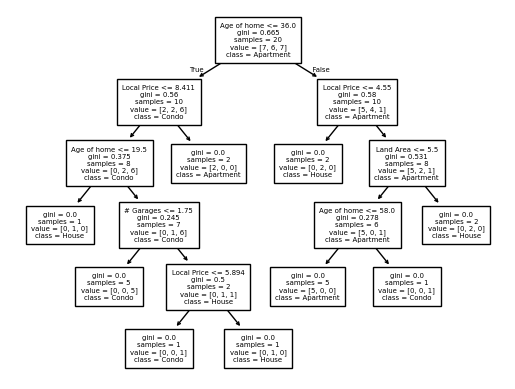

In [9]:
# The labels returned from the decision tree are in the order that they appear in the training data
dt_labels = list(df_train[TARGET_COL])
temp = set()
while len(dt_labels) > len(temp):
    i = len(temp)
    x = dt_labels[i]
    if x in temp:
        dt_labels.pop(i)
    else:
        temp.add(x)
del temp

plot_tree(depth_tests[-1], fontsize=5, feature_names=FEATURE_COLS, class_names=dt_labels)
plt.show()

In [10]:
tree = depth_tests[-1].tree_
L = tree.children_left
R = tree.children_right

def describe_feature(node_id, is_less):
    return f"$\\text{{{FEATURE_COLS[tree.feature[node_id]].replace("#", "\\#")}}} {"\\le" if is_less else ">"} {tree.threshold[node_id]:.3f}$"
def join_func(f, node_id, is_less):
    return lambda row: f(row) and is_less == (row[FEATURE_COLS[tree.feature[node_id]]] <= tree.threshold[node_id])

md = "| Antecedents | Consequent | Coverage | Accuracy |\n"
md += "|-|-|-|-|\n"
stack = [(0, [], lambda _: True)]
while stack:
    node_id, feats, func = stack.pop()
    if L[node_id] != R[node_id]:
        stack.append((R[node_id], feats + [describe_feature(node_id, False)], join_func(func, node_id, False)))
        stack.append((L[node_id], feats + [describe_feature(node_id, True)], join_func(func, node_id, True)))
    else:
        cls = dt_labels[np.argmax(tree.value[node_id])]
        covg = tree.n_node_samples[node_id] / len(df_train)
        matching_samples = list(filter(func, df_train.iloc))
        acc = "N/A"
        if len(matching_samples) > 0:
            acc = f"{sum(int(row[TARGET_COL] == cls) for row in matching_samples) / len(matching_samples) * 100:.2f}"
        md += f"| ({", ".join(feats)}) | {cls} | ${covg * 100:.2f}\\%$ | ${acc}\\%$ |\n"
display(Markdown(md))

| Antecedents | Consequent | Coverage | Accuracy |
|-|-|-|-|
| ($\text{Age of home} \le 36.000$, $\text{Local Price} \le 8.411$, $\text{Age of home} \le 19.500$) | House | $5.00\%$ | $0.00\%$ |
| ($\text{Age of home} \le 36.000$, $\text{Local Price} \le 8.411$, $\text{Age of home} > 19.500$, $\text{\# Garages} \le 1.750$) | Condo | $25.00\%$ | $0.00\%$ |
| ($\text{Age of home} \le 36.000$, $\text{Local Price} \le 8.411$, $\text{Age of home} > 19.500$, $\text{\# Garages} > 1.750$, $\text{Local Price} \le 5.894$) | Condo | $5.00\%$ | $0.00\%$ |
| ($\text{Age of home} \le 36.000$, $\text{Local Price} \le 8.411$, $\text{Age of home} > 19.500$, $\text{\# Garages} > 1.750$, $\text{Local Price} > 5.894$) | House | $5.00\%$ | $0.00\%$ |
| ($\text{Age of home} \le 36.000$, $\text{Local Price} > 8.411$) | Apartment | $10.00\%$ | $100.00\%$ |
| ($\text{Age of home} > 36.000$, $\text{Local Price} \le 4.550$) | House | $10.00\%$ | $0.00\%$ |
| ($\text{Age of home} > 36.000$, $\text{Local Price} > 4.550$, $\text{Land Area} \le 5.500$, $\text{Age of home} \le 58.000$) | Apartment | $25.00\%$ | $100.00\%$ |
| ($\text{Age of home} > 36.000$, $\text{Local Price} > 4.550$, $\text{Land Area} \le 5.500$, $\text{Age of home} > 58.000$) | Condo | $5.00\%$ | $0.00\%$ |
| ($\text{Age of home} > 36.000$, $\text{Local Price} > 4.550$, $\text{Land Area} > 5.500$) | House | $10.00\%$ | $0.00\%$ |
